# Preprocessing

Loads raw data from `DATA_ROOT` and prepares the analysis-ready tables.

`DATA_ROOT` is set in two ways depending on environment:
- **Local**: read from `.env` in the project root (copy `.env.example` → `.env` and set your path)
- **Colab**: mount Google Drive in the cell below, then set `DATA_ROOT` to the Drive path

In [1]:
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_ROOT = "/content/drive/My Drive/my_projects/M.A. Parliament/Code and Data/data"
else:
    if "DATA_ROOT" not in os.environ:
        try:
            from dotenv import load_dotenv, find_dotenv
            load_dotenv(find_dotenv())
        except ImportError:
            pass
    DATA_ROOT = os.environ.get("DATA_ROOT", "")

print("DATA_ROOT:", DATA_ROOT)
assert DATA_ROOT and os.path.isdir(DATA_ROOT), f"DATA_ROOT not set or missing: {DATA_ROOT!r}"

DATA_ROOT: /Users/anna/Library/CloudStorage/GoogleDrive-anle.werner.01@gmail.com/My Drive/my_projects/M.A. Parliament/Code and Data/data


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW  = Path(DATA_ROOT) / 'raw'
PROC = Path(DATA_ROOT) / 'processed'
V3   = RAW / 'stateparl_v3_parquet'   # StateParl v3 (current)

## StateParl v3 — paragraphs

16,078,467 rows × 14 columns (2000–2025, all 16 states).

Key v3 column changes from v2:
- `id` → `paragraph_id`, `protocol` → `protocol_id`, `sequence_number` → `protocol_position`
- `speaker_name` → `speaker_paragraph`, `speaker_id` → `mandate_id`
- New: `speech_id` (FK to speeches table), `segment_position`, `page`
- Affiliation `ijn` renamed to `nsc` (non-speech content)

In [3]:
paragraphs = pd.read_parquet(V3 / "stateparl_v3_paragraphs.parquet")
print(paragraphs.shape)
print(paragraphs.columns.tolist())
paragraphs.head(15)

(16078467, 14)
['paragraph_id', 'protocol_id', 'state', 'period', 'nth', 'date', 'speech_id', 'protocol_position', 'segment_position', 'page', 'speaker_paragraph', 'mandate_id', 'affiliation', 'content']


,paragraph_id,protocol_id,state,period,nth,date,speech_id,protocol_position,segment_position,page,speaker_paragraph,mandate_id,affiliation,content
0,1,bb_3_10,bb,3,10,2000-02-24,NaN,1,2,4,Knoblich,bb_3_pre_knoblich,pre,Werte Kolleginnen und Kollegen! Ich begrüße Si...
1,2,bb_3_10,bb,3,10,2000-02-24,NaN,2,3,4,,,nsc,(Allgemeiner Beifall)
2,3,bb_3_10,bb,3,10,2000-02-24,NaN,3,4,4,Knoblich,bb_3_pre_knoblich,pre,Nicht weniger herzlich begrüße ich unsere Stam...
3,4,bb_3_10,bb,3,10,2000-02-24,NaN,4,5,4,Knoblich,bb_3_pre_knoblich,pre,Mit der Einladung ist Ihnen der Vorschlag zur ...
4,5,bb_3_10,bb,3,10,2000-02-24,NaN,5,6,4,Knoblich,bb_3_pre_knoblich,pre,"Ich darf darauf hinweisen, dass die DVU-Frakti..."
5,6,bb_3_10,bb,3,10,2000-02-24,NaN,6,7,4,Knoblich,bb_3_pre_knoblich,pre,Damit darf ich um Ihr zustimmendes Handzeichen...
6,7,bb_3_10,bb,3,10,2000-02-24,NaN,7,8,4,Knoblich,bb_3_pre_knoblich,pre,"Ich merke gerade, dass es notwendig gewesen wä..."
7,8,bb_3_10,bb,3,10,2000-02-24,NaN,8,9,4,Knoblich,bb_3_pre_knoblich,pre,"Es wird vorgeschlagen, einen neuen Tagesordnun..."
8,9,bb_3_10,bb,3,10,2000-02-24,NaN,9,10,4,Knoblich,bb_3_pre_knoblich,pre,Außerdem wird ein neuer Tagesordnungspunkt 11 ...
9,10,bb_3_10,bb,3,10,2000-02-24,NaN,10,11,4,Knoblich,bb_3_pre_knoblich,pre,"Schließlich wird vorgeschlagen, einen Tagesord..."


## Parsed nsc output — visual inspection

Output of `preprocessing/nsc_rule_parser.py` → `DATA_ROOT/processed/nsc.parquet`.
Load this section independently — `nsc_df` does not depend on the tables above.

**Multi-segment rows**: when a source nsc row contains multiple events (e.g.
`"Beifall CDU – Zuruf von der SPD: Das stimmt!"`), each event becomes its own output
row with the same `paragraph_id`. `segment_idx` gives position within the source row
(0-based); `n_segments` gives total count.

**Glocke processing**: rows containing `Glocke*` and < 80 chars get
`nsc_type = "glocke"`. `speaker_name` is extracted from `"Glocke des Präsidenten"` →
`"Präsident"`, `role = "Präsident/in"` (~70% of glocke rows have an extractable speaker).
Glocke rows are single-segment (never split) and appear in the output alongside interjections.

In [4]:
_NON_INJ = {"glocke", "Prozedural", "mislabelled", "noise", "garbled"}

nsc_df = pd.read_parquet(PROC / "nsc.parquet")
nsc    = nsc_df[~nsc_df["nsc_type"].isin(_NON_INJ)].reset_index(drop=True)

print(f"Segments total:  {len(nsc_df):,}")
print(f"Interjections:   {len(nsc):,}  ({100*len(nsc)/len(nsc_df):.1f}%)")

print("\n── nsc_type breakdown (per source row) ────────────────────")
rt = nsc_df.drop_duplicates("paragraph_id")["nsc_type"].value_counts()
print(rt.to_string())

print("\n── nsc_type (interjection rows only) ──────────────────────")
it = nsc["nsc_type"].value_counts()
print(pd.concat([it, (it/len(nsc)*100).round(1).rename("%")], axis=1).to_string())

print("\n── Unknown rate + named-speaker rate by state ─────────────")
sg = (
    nsc.groupby("state")
    .apply(lambda g: pd.Series({
        "n":         len(g),
        "pct_unk":   round((g["nsc_type"] == "unknown").mean() * 100, 1),
        "pct_named": round(g["is_named_speaker"].mean() * 100, 1),
    }), include_groups=False)
    .sort_values("pct_unk", ascending=False)
)
print(sg.to_string())

Segments total:  4,920,872
Interjections:   4,825,846  (98.1%)

── nsc_type breakdown (per source row) ────────────────────


nsc_type
Beifall                                   1988822
Zwischenruf                               1320062
Zuruf                                      456497
Heiterkeit                                  79049
Zustimmung                                  78464
Unruhe                                      61946
glocke                                      48782
Lachen                                      29891
Prozedural                                  26216
unknown                                     22740
Beifall|Heiterkeit                          20391
mislabelled                                 17455
Widerspruch                                 13011
Beifall|Zustimmung                          11566
Ausruf                                       7814
Beifall|Zuruf                                4870
noise                                        2573
Heiterkeit|Zuruf                             2319
Gelächter                                    2258
Beifall|Lachen                           

In [5]:
_DISP_COLS = ["state", "nsc_type", "qualifier", "speaker_name", "role", "title",
              "party_canonical", "content_text", "raw_segment"]

def inspect(nsc_type=None, state=None, party=None, named=None,
            include_glocke=False, n=20, seed=42):
    """Sample nsc segments for visual inspection.

    Examples
    --------
    inspect(nsc_type="unknown", state="st")
    inspect(nsc_type="Zuruf", party="AfD")
    inspect(nsc_type="Beifall", named=True)
    inspect(include_glocke=True, n=20)
    inspect(nsc_type="unknown", n=50, seed=7)
    """
    df = nsc_df if include_glocke else nsc
    if nsc_type is not None:
        df = df[df["nsc_type"] == nsc_type]
    if state is not None:
        df = df[df["state"] == state]
    if party is not None:
        df = df[df["party_canonical"].str.contains(party, case=False, na=False)]
    if named is not None:
        df = df[df["is_named_speaker"] == named]
    sample = df[_DISP_COLS].sample(min(n, len(df)), random_state=seed)
    print(f"{len(df):,} matching → showing {len(sample)}\n")
    for _, r in sample.iterrows():
        meta = "  |  ".join(
            str(v) for v in [r["speaker_name"], r["role"], r["title"], r["party_canonical"]]
            if pd.notna(v) and str(v).strip() not in ("", "nan")
        )
        print(f"[{r['state']} · {r['nsc_type']}]  {meta}")
        print(f"  {r['raw_segment']}\n")
    return sample

inspect(nsc_type="unknown", n=30)

36,453 matching → showing 30

[hh · unknown]  
  darum!

[nw · unknown]  
  Josef Hovenjürgen [CDU] spricht mit einem anderen Abgeordneten.

[be · unknown]  
  Das war echt frech, Herr Präsident!

[ni · unknown]  
  nicht so wie beim letzten Mal!

[sh · unknown]  
  Befall BÜNDNIS 90/DIE GRÜNEN, CDU und FDP

[st · unknown]  
  fertig!

[rp · unknown]  
  Vizepräsidentin Kathrin Anklam-Trapp übernimmt den Vorsitz

[st · unknown]  
  Matthias Böttner, Staßfurt, AfD: Da sind sie, die Nationalsozialisten!

[sn · unknown]  
  Prof. Dr. Karl Mannsfeld, CDU, steht am Mikrofon.

[sn · unknown]  
  Auf der Rückseite des Rednermanuskripts steht offenbar etwas die FDP-Fraktion Erheiterndes.

[bw · unknown]  
  Stellv. Präsident Dr. Wolfgang Reinhart niest.

[sn · unknown]  
  Sabine Friedel, SPD, steht am Mikrofon.

[st · unknown]  
  Christian Hecht, AfD, lacht

[sl · unknown]  
  Der Redner umreißt mit einer Armbewegung den Bildausschnitt

[bb · unknown]  
  Frau Schmidt: Ich schwöre es.

[ni ·

,state,nsc_type,qualifier,speaker_name,role,title,party_canonical,content_text,raw_segment
1905009,hh,unknown,,,,,,,darum!
3283936,nw,unknown,,,,,,,Josef Hovenjürgen [CDU] spricht mit einem ande...
183728,be,unknown,,,,,,,"Das war echt frech, Herr Präsident!"
2957066,ni,unknown,,,,,,,nicht so wie beim letzten Mal!
3964605,sh,unknown,,,,,,,"Befall BÜNDNIS 90/DIE GRÜNEN, CDU und FDP"
4486560,st,unknown,,,,,,,fertig!
3673834,rp,unknown,,,,,,,Vizepräsidentin Kathrin Anklam-Trapp übernimmt...
4552671,st,unknown,,,,,,,"Matthias Böttner, Staßfurt, AfD: Da sind sie, ..."
4147631,sn,unknown,,,,,,,"Prof. Dr. Karl Mannsfeld, CDU, steht am Mikrofon."
4139085,sn,unknown,,,,,,,Auf der Rückseite des Rednermanuskripts steht ...


In [6]:
unk = nsc[nsc["nsc_type"] == "unknown"].reset_index(drop=True)
print(f"Unknowns: {len(unk):,}  ({100*len(unk)/len(nsc):.2f}% of interjections)\n")

tok = unk["raw_segment"].str.lower().str.extract(r'^([a-zäöüß\-\.]{2,25})')[0]
print("── Top leading token of unknown rows ──────────────────────")
print(tok.value_counts().head(30).to_string())

print("\n── Unknown count by state ─────────────────────────────────")
print(unk["state"].value_counts().to_string())

print("\n── 15 random unknowns ─────────────────────────────────────")
for r in unk["raw_segment"].sample(15, random_state=7):
    print(f"  {r[:100]!r}")

Unknowns: 36,453  (0.76% of interjections)

── Top leading token of unknown rows ──────────────────────
0
der                2777
die                2344
dr.                1510
vizepräsidentin    1230
das                1010
abg.                906
frau                861
unterbrechung       804
herr                787
matthias            763
schluss             608
dirk                466
vizepräsident       442
abgeordneter        414
norbert             400
minister            343
schriftführer       315
präsidentin         306
beitrag             241
schriftführerin     235
zur                 229
aufruf              226
eine                222
dem                 208
cdu                 205
christian           202
zwei                189
rbm                 176
stephan             170
prof.               169

── Unknown count by state ─────────────────────────────────
state
st    4721
mv    4592
ni    4405
sn    3338
he    2678
hh    2487
be    2166
nw    2116
bw    1738
sh    16

In [7]:
stats = (
    nsc.groupby("nsc_type", sort=False)
    .agg(
        n          = ("paragraph_id", "count"),
        pct_named  = ("is_named_speaker", lambda g: round(g.mean() * 100, 1)),
        mean_len   = ("content_text",     lambda g: round(g.str.len().mean(), 1)),
    )
    .assign(share_pct=lambda d: (d["n"] / len(nsc) * 100).round(1))
    [["n", "share_pct", "pct_named", "mean_len"]]
    .sort_values("n", ascending=False)
)
stats.columns = ["N", "share %", "named speaker %", "mean content len"]
stats

,N,share %,named speaker %,mean content len
nsc_type,,,,
Beifall,2051818,42.5,7.3,6.9
Zwischenruf,1639554,34.0,99.9,27.2
Zuruf,665097,13.8,53.0,4.8
Heiterkeit,99599,2.1,23.8,5.5
Zustimmung,88052,1.8,20.3,7.2
...,...,...,...,...
Gegenruf|Zwischenruf,1,0.0,0.0,37.0
Beifall|Gegenruf|Heiterkeit|Zuruf,1,0.0,0.0,7.0
Beifall|Gegenruf|Widerspruch,1,0.0,0.0,7.0


In [8]:
# Interjection count: party × state
# segment_idx == 0 → one event per source paragraph (avoids double-counting multi-segment rows)
_inj = nsc[nsc["segment_idx"] == 0]
pd.crosstab(
    _inj["party_canonical"].fillna("—"),
    _inj["state"],
    margins=True, margins_name="Total",
).sort_values("Total", ascending=False)

state,bb,be,bw,by,hb,he,hh,mv,ni,nw,rp,sh,sl,sn,st,th,Total
party_canonical,,,,,,,,,,,,,,,,,
Total,153353,214654,403133,233793,147593,352283,239778,459808,348507,341538,194701,298104,63363,195982,208594,257351,4112535
CDU,17639,26995,28702,0,28958,46104,42693,100594,78391,48633,56591,26938,8435,33396,38496,54954,637519
SPD,18320,19288,26182,56114,23087,59647,47865,77778,56545,77205,43298,31958,13171,18557,20642,27050,616707
,13301,9796,186820,17491,24874,18436,41435,13271,15870,17813,14182,72729,9359,10642,32152,42505,540676
GRÜNE,6131,30189,22030,39644,10593,36675,15128,17947,43313,43359,13500,19522,2921,12501,16465,26314,356232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GRÜNE|FW|SPD|OTHER|FDP,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
GRÜNE|FW|SPD|FDP|CSU,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
GRÜNE|FW|SPD|CSU,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1


In [9]:
# Count by nsc_type × state
pd.crosstab(
    _inj["nsc_type"],
    _inj["state"],
    margins=True, margins_name="Total",
).sort_values("Total", ascending=False)

state,bb,be,bw,by,hb,he,hh,mv,ni,nw,rp,sh,sl,sn,st,th,Total
nsc_type,,,,,,,,,,,,,,,,,
Total,153353,214654,403133,233793,147593,352283,239778,459808,348507,341538,194701,298104,63363,195982,208594,257351,4112535
Beifall,87092,120929,137955,139102,97404,212571,129522,98751,174036,194681,103059,165576,32092,100855,59671,135526,1988822
Zwischenruf,31973,55817,186349,52476,36913,83577,90785,231186,97335,85895,56456,90032,21257,52410,48427,99174,1320062
Zuruf,21109,26354,51290,25621,6739,38861,12040,88244,22218,43432,26402,27107,5336,27496,30131,4117,456497
Heiterkeit,3306,3656,10270,3020,2495,5078,1255,20364,3639,4047,4050,4682,767,3966,3651,4803,79049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Beifall|Unruhe|Widerspruch|Zuruf,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
Beifall|Lachen|Zustimmung,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
Beifall|Heiterkeit|Zwischenruf,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [10]:
# Zwischenrufe only: party × state
_zr = _inj[_inj["nsc_type"] == "Zwischenruf"]
pd.crosstab(
    _zr["party_canonical"].fillna("—"),
    _zr["state"],
    margins=True, margins_name="Total",
).sort_values("Total", ascending=False)

state,bb,be,bw,by,hb,he,hh,mv,ni,nw,rp,sh,sl,sn,st,th,Total
party_canonical,,,,,,,,,,,,,,,,,
Total,31973,55817,186349,52476,36913,83577,90785,231186,97335,85895,56456,90032,21257,52410,48427,99174,1320062
,1683,1733,159565,1274,5460,3056,23372,4039,1624,9401,4061,49118,5234,3565,2776,37378,313339
SPD,7426,6398,458,20812,6649,25037,28626,47847,24190,32100,20449,10137,4997,7436,6306,8222,257090
CDU,5338,8488,525,0,10720,19158,19672,58249,35888,11993,18659,9064,4304,9491,14105,17408,243062
LINKE,7911,11186,4,0,2049,8351,4139,61624,3703,1758,0,182,3045,14746,8115,17675,144488
GRÜNE,1197,10326,1921,8709,7755,13878,8508,9064,18125,13344,5072,4016,1851,3984,5221,7892,120863
FDP,147,7096,22705,1423,2390,10472,3740,7711,12408,10553,2607,13806,175,916,4082,4078,104309
AfD,6663,5844,220,1183,157,3579,2682,19201,1343,3677,4891,757,1066,6348,7444,5139,70194
NPD,0,0,0,0,0,0,0,22485,0,0,0,0,0,3252,0,0,25737


In [11]:
import ipywidgets as w
from IPython.display import display

_types = sorted(nsc["nsc_type"].unique())

dd    = w.Dropdown(options=_types, description="Type:", layout=w.Layout(width="200px"))
btn   = w.Button(description="Next sample", button_style="primary")
n_sl  = w.IntSlider(value=10, min=3, max=30, step=1, description="n rows:")
out   = w.Output()

def _show(_):
    out.clear_output(wait=True)
    with out:
        sample = inspect(nsc_type=dd.value, n=n_sl.value, seed=None)
        display(sample)

btn.on_click(_show)
_show(None)
display(w.HBox([dd, n_sl, btn]), out)

Output()

In [12]:
# ── AfD presence intervals, derived directly from the corpus ────────────────
# Period-level presence: a (state, period) counts as "AfD present" if ANY row in
# it has affiliation == "afd". Interval bounds are the PERIOD's own first/last
# sitting dates (not just the afd rows' dates) — verified against the full
# corpus: the gap between a period's constitutive session and the first
# afd-affiliated row in it is 0 days for 10/16 states, and at most 29 days for
# the rest (mv, sl) — AfD's mandate effectively starts at the constitutive
# session, not at some later point mid-period.
#
# This also captures exit/re-entry directly, which a single "entry year"
# marker (the previous afd_entry.xlsx-based approach, year-only precision)
# could not represent at all: Bremen held AfD seats in periods 19-20 only
# (2015-07-01 to 2023-04-26) then none in period 21; Schleswig-Holstein held
# AfD seats in period 19 only (2017-06-06 to 2022-04-28) then none in period 20.
try:
    _par_afd = paragraphs[["state", "period", "date", "affiliation"]]
except NameError:
    _par_afd = pd.read_parquet(
        V3 / "stateparl_v3_paragraphs.parquet",
        columns=["state", "period", "date", "affiliation"],
    )

_par_afd = _par_afd.assign(date=pd.to_datetime(_par_afd["date"]))
_period_bounds = (
    _par_afd.groupby(["state", "period"])["date"]
    .agg(["min", "max"])
    .rename(columns={"min": "start", "max": "end"})
)
_afd_periods = set(
    _par_afd.loc[_par_afd["affiliation"] == "afd", ["state", "period"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

AFD_PRESENCE: dict[str, list[tuple[pd.Timestamp, pd.Timestamp]]] = {}
for (state, period), row in _period_bounds.iterrows():
    if (state, period) in _afd_periods:
        AFD_PRESENCE.setdefault(state, []).append((row["start"], row["end"]))

# Merge adjacent AfD-holding periods into one contiguous interval (cosmetic —
# e.g. bb's three consecutive AfD periods render as one shaded block, not three).
for state, intervals in AFD_PRESENCE.items():
    intervals.sort()
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        if start <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))
        else:
            merged.append((start, end))
    AFD_PRESENCE[state] = merged

for state, intervals in sorted(AFD_PRESENCE.items()):
    print(state, [(s.date(), e.date()) for s, e in intervals])


bb [(datetime.date(2014, 10, 8), datetime.date(2019, 6, 13)), (datetime.date(2019, 9, 25), datetime.date(2024, 8, 29)), (datetime.date(2024, 10, 17), datetime.date(2025, 12, 18))]
be [(datetime.date(2016, 10, 27), datetime.date(2021, 9, 16)), (datetime.date(2021, 11, 4), datetime.date(2025, 12, 18))]
bw [(datetime.date(2016, 5, 11), datetime.date(2021, 3, 24)), (datetime.date(2021, 5, 11), datetime.date(2025, 12, 11))]
by [(datetime.date(2018, 11, 5), datetime.date(2023, 7, 20)), (datetime.date(2023, 10, 30), datetime.date(2025, 12, 11))]
hb [(datetime.date(2015, 7, 1), datetime.date(2019, 5, 9)), (datetime.date(2019, 7, 3), datetime.date(2023, 4, 26))]
he [(datetime.date(2019, 1, 18), datetime.date(2023, 12, 12)), (datetime.date(2024, 1, 18), datetime.date(2025, 12, 11))]
hh [(datetime.date(2015, 9, 16), datetime.date(2020, 2, 12)), (datetime.date(2020, 3, 18), datetime.date(2024, 12, 16))]
mv [(datetime.date(2016, 10, 4), datetime.date(2021, 6, 11)), (datetime.date(2021, 10, 26), dat

## NSC time series — monthly counts and shares

Merge parsed nsc data back onto paragraphs, then aggregate to monthly totals.

- **Count**: raw NSC event count per month (one per source paragraph; multi-segment rows deduplicated via `segment_idx == 0`).
- **Share**: NSC events as % of all paragraphs in that month (denominator includes speech + nsc rows).
- **By party**: based on `affiliation_derived` column; major parties only (cdu / spd / grn / fdp / lin / afd).
  Share = party's monthly NSC count / total monthly NSC count.


In [ ]:
import sys
from pathlib import Path

_cwd = Path(".").resolve()
_repo = _cwd if (_cwd / "utils" / "colors.py").exists() else _cwd.parent
if str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))
from utils.colors import AFFILIATION_COLORS, NSC_TYPE_COLORS, NAVY, GOLD
from preprocessing.nsc_rule_parser import NON_INTERJECTION_TYPES

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# ── Load paragraphs (minimal columns) for monthly denominator ───────────────
try:
    _par = paragraphs[["paragraph_id", "date", "affiliation", "state"]].copy()
    print("Using paragraphs already in memory.")
except NameError:
    print("Loading paragraphs …")
    _par = pd.read_parquet(
        V3 / "stateparl_v3_paragraphs.parquet",
        columns=["paragraph_id", "date", "affiliation", "state"],
    )

_par["month"] = pd.to_datetime(_par["date"]).dt.to_period("M")
monthly_total  = _par.groupby("month").size().rename("n_total")
monthly_speech = (
    _par[_par["affiliation"] != "nsc"].groupby("month").size().rename("n_speech")
)

# ── Interjection rows: one per source paragraph ─────────────────────────────
_NON_INJ = NON_INTERJECTION_TYPES
inj = nsc_df[
    (nsc_df["segment_idx"] == 0) & (~nsc_df["nsc_type"].isin(_NON_INJ))
].copy()
inj["month"] = pd.to_datetime(inj["date"]).dt.to_period("M")
monthly_nsc = inj.groupby("month").size().rename("n_nsc")

# ── Combined monthly frame ──────────────────────────────────────────────────
monthly = (
    pd.concat([monthly_total, monthly_speech, monthly_nsc], axis=1)
    .sort_index()
    .loc["2000-01":"2025-06"]
)
monthly["share_pct"] = monthly["n_nsc"] / monthly["n_total"] * 100
monthly.index = monthly.index.to_timestamp()

# ── By major party (affiliation_derived uses lowercase codes) ────────────────
# affiliation_derived: lowercase canonical codes — "cdu", "spd", "grn", "fdp", "lin", "afd"
# party_canonical:     uppercase canonical names — "CDU", "SPD", "GRÜNE", "FDP", "LINKE", "AfD"
MAJOR_AFF       = ["cdu", "spd", "grn", "fdp", "lin", "afd"]
MAJOR_CANONICAL = ["CDU", "CSU", "SPD", "GRÜNE", "FDP", "LINKE", "AfD"]
AFF_LABELS      = {"cdu": "CDU/CSU", "spd": "SPD", "grn": "GRÜNE",
                   "fdp": "FDP", "lin": "LINKE", "afd": "AfD"}

party_monthly_count = (
    inj[inj["affiliation_derived"].isin(MAJOR_AFF)]
    .groupby(["month", "affiliation_derived"]).size()
    .unstack("affiliation_derived").fillna(0)
    .sort_index()
    .loc["2000-01":"2025-06"]
)
party_monthly_count.index = party_monthly_count.index.to_timestamp()

party_monthly_share = party_monthly_count.div(monthly_nsc.reindex(
    party_monthly_count.index.to_period("M")
).values, axis=0) * 100

# ── By interjection type ────────────────────────────────────────────────────
TYPE_ORDER = ["Beifall", "Zwischenruf", "Zuruf", "Heiterkeit",
              "Zustimmung", "Unruhe", "Widerspruch", "Ausruf"]
inj["primary_type"] = inj["nsc_type"].str.split("|").str[0]

type_monthly_count = (
    inj[inj["primary_type"].isin(TYPE_ORDER)]
    .groupby(["month", "primary_type"]).size()
    .unstack("primary_type").fillna(0)
    .reindex(columns=TYPE_ORDER, fill_value=0)
    .sort_index()
    .loc["2000-01":"2025-06"]
)
type_monthly_count.index = type_monthly_count.index.to_timestamp()

type_monthly_share = type_monthly_count.div(
    monthly_nsc.reindex(type_monthly_count.index.to_period("M")).values, axis=0
) * 100

ROLL = 6
monthly_r     = monthly.rolling(ROLL, center=True, min_periods=3)
party_count_r = party_monthly_count.rolling(ROLL, center=True, min_periods=3)
party_share_r = party_monthly_share.rolling(ROLL, center=True, min_periods=3)
type_count_r  = type_monthly_count.rolling(ROLL, center=True, min_periods=3)
type_share_r  = type_monthly_share.rolling(ROLL, center=True, min_periods=3)

# ── By state: Zwischenruf / Zuruf ───────────────────────────────────────────
# str.contains handles compound nsc_types ("Zwischenruf|Heiterkeit" still counts).
_zr_mask   = inj["nsc_type"].str.contains("Zwischenruf", na=False)
_zrzr_mask = inj["nsc_type"].str.contains(r"Zwischenruf|Zuruf", na=False)

def _state_ts(mask):
    s = (
        inj[mask].groupby(["month", "state"]).size()
        .unstack("state", fill_value=0)
        .sort_index().loc["2000-01":"2025-06"]
    )
    out = s.copy(); out.index = s.index.to_timestamp()
    return out

state_monthly_zr   = _state_ts(_zr_mask)
state_monthly_zrzr = _state_ts(_zrzr_mask)

# ── Party × state (exploded on party_canonical, Zwischenruf + Zuruf) ─────────
# party_canonical is pipe-separated uppercase names: "CDU|SPD", "GRÜNE", "AfD" …
# Explode so each party earns one count per event.
_exp = (
    inj[_zrzr_mask]
    .assign(party=lambda d: d["party_canonical"].str.split("|"))
    .explode("party")
)
_exp = _exp[_exp["party"].isin(MAJOR_CANONICAL)]

_ps = (
    _exp.groupby(["month", "state", "party"]).size()
    .unstack(["state", "party"], fill_value=0)
    .sort_index().loc["2000-01":"2025-06"]
)
_ps.index = _ps.index.to_timestamp()
state_party_monthly = _ps   # MultiIndex columns: (state, party)

# Share = party's monthly count as % of that state's total Zwischenruf+Zuruf
# events (per-state denominator, since parliament sizes vary — not the
# nationwide total used for party_monthly_share above).
state_party_share = state_party_monthly.apply(
    lambda col: col / state_monthly_zrzr[col.name[0]] * 100
)

print(f"Monthly frame: {monthly.index[0].date()} – {monthly.index[-1].date()}, {len(monthly)} months")
print(f"Total NSC events (interjections): {monthly['n_nsc'].sum():,.0f}")
print(f"Zwischenruf rows: {_zr_mask.sum():,}   Zwischenruf+Zuruf: {_zrzr_mask.sum():,}")
print(f"Party×state columns: {state_party_monthly.shape[1]}  (states × parties after explosion)")

**Gesamtverlauf: Anzahl und Anteil aller NSC-Interjektionen, 2000–2025**

- **Daten:** alle NSC-Interjektionen (`segment_idx == 0`), aggregiert über alle 16 Bundesländer und alle Parteien.
- **Links:** absolute monatliche Anzahl (in Tausend). **Rechts:** NSC-Anteil = NSC-Ereignisse / Gesamtzahl aller Absätze des Monats (%).
- **Visualisierung:** blasse Linie = Rohdaten pro Monat; durchgezogene Linie = 6-Monats-zentrierter gleitender Durchschnitt.

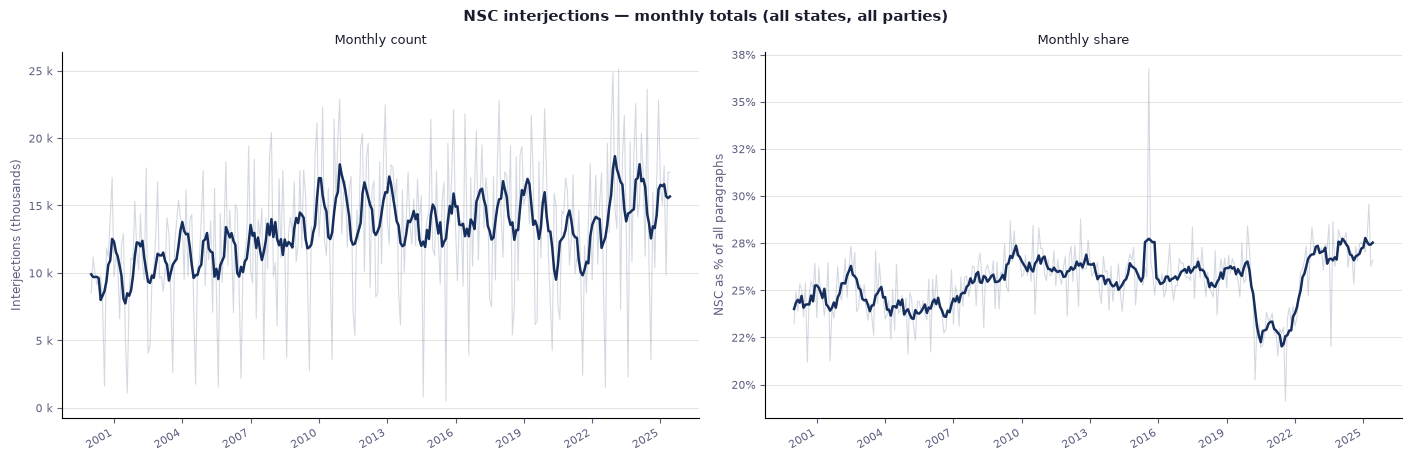

In [14]:
fig, (ax_cnt, ax_shr) = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
fig.suptitle("NSC interjections — monthly totals (all states, all parties)",
             fontsize=11, fontweight="bold", x=0.5, color="#1A1D2E")

for ax in (ax_cnt, ax_shr):
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8, colors="#5C6080")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.grid(axis="y", color="#E1E0D9", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

# ── count ──────────────────────────────────────────────────────────────────
ax_cnt.plot(monthly.index, monthly["n_nsc"] / 1_000,
            color=NAVY, alpha=0.18, linewidth=0.8)
ax_cnt.plot(monthly.index, monthly_r.mean()["n_nsc"] / 1_000,
            color=NAVY, linewidth=1.8, label="6-month avg")
ax_cnt.set_ylabel("Interjections (thousands)", fontsize=8.5, color="#5C6080")
ax_cnt.set_title("Monthly count", fontsize=9.5, pad=6, color="#1A1D2E")
ax_cnt.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f k"))

# ── share ──────────────────────────────────────────────────────────────────
ax_shr.plot(monthly.index, monthly["share_pct"],
            color=NAVY, alpha=0.18, linewidth=0.8)
ax_shr.plot(monthly.index, monthly_r.mean()["share_pct"],
            color=NAVY, linewidth=1.8, label="6-month avg")
ax_shr.set_ylabel("NSC as % of all paragraphs", fontsize=8.5, color="#5C6080")
ax_shr.set_title("Monthly share", fontsize=9.5, pad=6, color="#1A1D2E")
ax_shr.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))

plt.savefig(PROC / "plot_nsc_monthly_total.pdf", bbox_inches="tight")
plt.savefig(PROC / "plot_nsc_monthly_total.png", dpi=150, bbox_inches="tight")
plt.show()


**Monatliche NSC-Interjektionen nach Partei**

- **Daten:** sechs große Fraktionen (`affiliation_derived`): CDU/CSU, SPD, GRÜNE, FDP, LINKE, AfD.
- **Links:** absolute Anzahl (Tausend). **Rechts:** Anteil der Partei an allen NSC-Ereignissen des Monats (%).
- **Visualisierung:** je eine Linie pro Partei in konventionellen Parteifarben; blasse Linie = Rohdaten, durchgezogene = 6-Monats-Glättung.

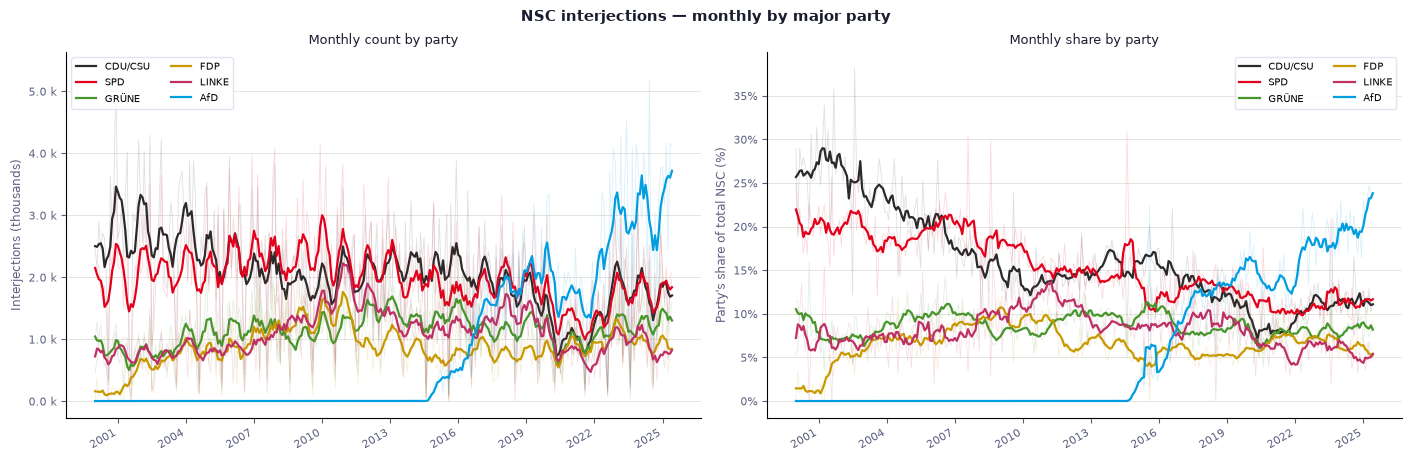

In [15]:
fig, (ax_cnt, ax_shr) = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
fig.suptitle("NSC interjections — monthly by major party",
             fontsize=11, fontweight="bold", x=0.5, color="#1A1D2E")

for ax in (ax_cnt, ax_shr):
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8, colors="#5C6080")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.grid(axis="y", color="#E1E0D9", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

for aff in MAJOR_AFF:
    if aff not in party_monthly_count.columns:
        continue
    c     = AFFILIATION_COLORS[aff]
    label = AFF_LABELS[aff]

    # count
    ax_cnt.plot(party_monthly_count.index, party_monthly_count[aff] / 1_000,
                color=c, alpha=0.15, linewidth=0.6)
    ax_cnt.plot(party_count_r.mean().index, party_count_r.mean()[aff] / 1_000,
                color=c, linewidth=1.6, label=label)

    # share
    ax_shr.plot(party_monthly_share.index, party_monthly_share[aff],
                color=c, alpha=0.15, linewidth=0.6)
    ax_shr.plot(party_share_r.mean().index, party_share_r.mean()[aff],
                color=c, linewidth=1.6, label=label)

ax_cnt.set_ylabel("Interjections (thousands)", fontsize=8.5, color="#5C6080")
ax_cnt.set_title("Monthly count by party", fontsize=9.5, pad=6, color="#1A1D2E")
ax_cnt.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.1f} k"))
ax_cnt.legend(fontsize=7.5, framealpha=0.85, edgecolor="#DDE1EF",
              loc="upper left", ncol=2)

ax_shr.set_ylabel("Party's share of total NSC (%)", fontsize=8.5, color="#5C6080")
ax_shr.set_title("Monthly share by party", fontsize=9.5, pad=6, color="#1A1D2E")
ax_shr.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax_shr.legend(fontsize=7.5, framealpha=0.85, edgecolor="#DDE1EF",
              loc="upper right", ncol=2)

plt.savefig(PROC / "plot_nsc_monthly_by_party.pdf", bbox_inches="tight")
plt.savefig(PROC / "plot_nsc_monthly_by_party.png", dpi=150, bbox_inches="tight")
plt.show()


**Monatliche NSC-Interjektionen nach Typ**

- **Daten:** acht Haupttypen (Beifall, Zwischenruf, Zuruf, Heiterkeit, Zustimmung, Unruhe, Widerspruch, Ausruf). Bei zusammengesetzten Typen (`Heiterkeit|Beifall`) zählt der erste Bezeichner.
- **Links:** absolute Anzahl (Tausend). **Rechts:** Anteil an allen NSC-Ereignissen des Monats (%).
- **Visualisierung:** Paul-Tol-Muted-Palette; blasse Linie = Rohdaten, durchgezogene = 6-Monats-Glättung.

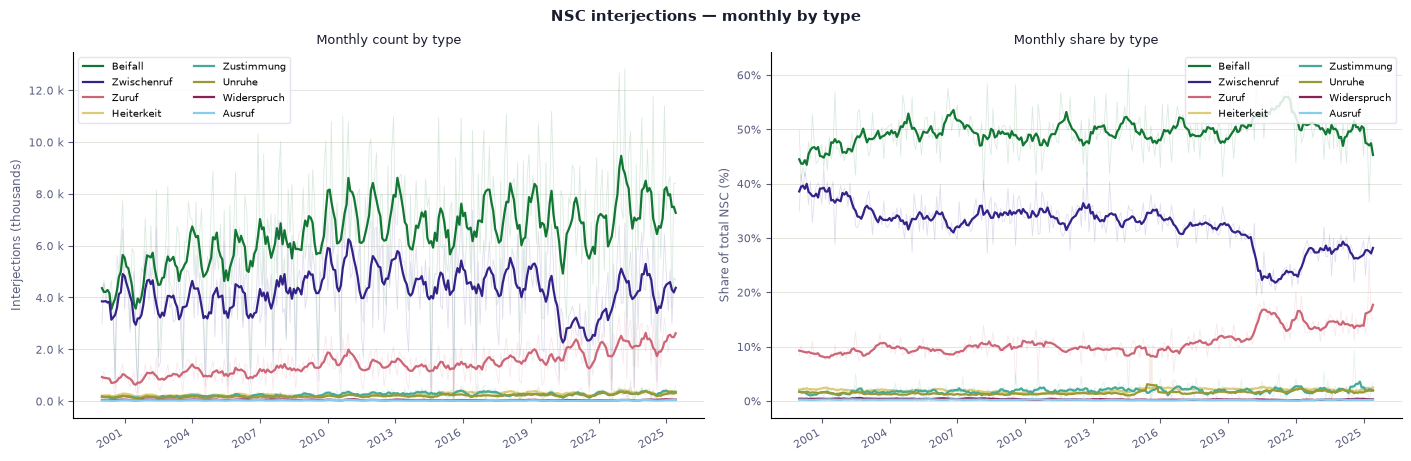

In [16]:
fig, (ax_cnt, ax_shr) = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
fig.suptitle("NSC interjections — monthly by type",
             fontsize=11, fontweight="bold", x=0.5, color="#1A1D2E")

for ax in (ax_cnt, ax_shr):
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8, colors="#5C6080")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.grid(axis="y", color="#E1E0D9", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

_tc = type_count_r.mean()
_ts = type_share_r.mean()

for typ in TYPE_ORDER:
    if typ not in type_monthly_count.columns:
        continue
    c = NSC_TYPE_COLORS.get(typ, "#898781")

    ax_cnt.plot(type_monthly_count.index, type_monthly_count[typ] / 1_000,
                color=c, alpha=0.15, linewidth=0.6)
    ax_cnt.plot(_tc.index, _tc[typ] / 1_000,
                color=c, linewidth=1.6, label=typ)

    ax_shr.plot(type_monthly_share.index, type_monthly_share[typ],
                color=c, alpha=0.15, linewidth=0.6)
    ax_shr.plot(_ts.index, _ts[typ],
                color=c, linewidth=1.6, label=typ)

ax_cnt.set_ylabel("Interjections (thousands)", fontsize=8.5, color="#5C6080")
ax_cnt.set_title("Monthly count by type", fontsize=9.5, pad=6, color="#1A1D2E")
ax_cnt.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.1f} k"))
ax_cnt.legend(fontsize=7.5, framealpha=0.85, edgecolor="#DDE1EF",
              loc="upper left", ncol=2)

ax_shr.set_ylabel("Share of total NSC (%)", fontsize=8.5, color="#5C6080")
ax_shr.set_title("Monthly share by type", fontsize=9.5, pad=6, color="#1A1D2E")
ax_shr.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax_shr.legend(fontsize=7.5, framealpha=0.85, edgecolor="#DDE1EF",
              loc="upper right", ncol=2)

plt.savefig(PROC / "plot_nsc_monthly_by_type.pdf", bbox_inches="tight")
plt.savefig(PROC / "plot_nsc_monthly_by_type.png", dpi=150, bbox_inches="tight")
plt.show()


**Monthly Zwischenruf / Zuruf counts by state — small multiples (4 × 4)**

- **Data:** verbal interjections only. Compound `nsc_type` values (e.g. `"Zwischenruf|Heiterkeit"`) count once if they contain the target keyword. One event per source paragraph (`segment_idx == 0`).
- **Figure A:** Zwischenruf only. **Figure B:** Zwischenruf + Zuruf combined. Y-axes not shared (parliament sizes vary).
- **Visualisation:** faint line = raw monthly count; solid line = 6-month centred rolling average; gold shaded region = period(s) during which AfD held seats in that state parliament (derived directly from the corpus — see `AFD_PRESENCE` above; correctly shows Bremen's and Schleswig-Holstein's exit as an unshaded gap, not just a single entry marker).


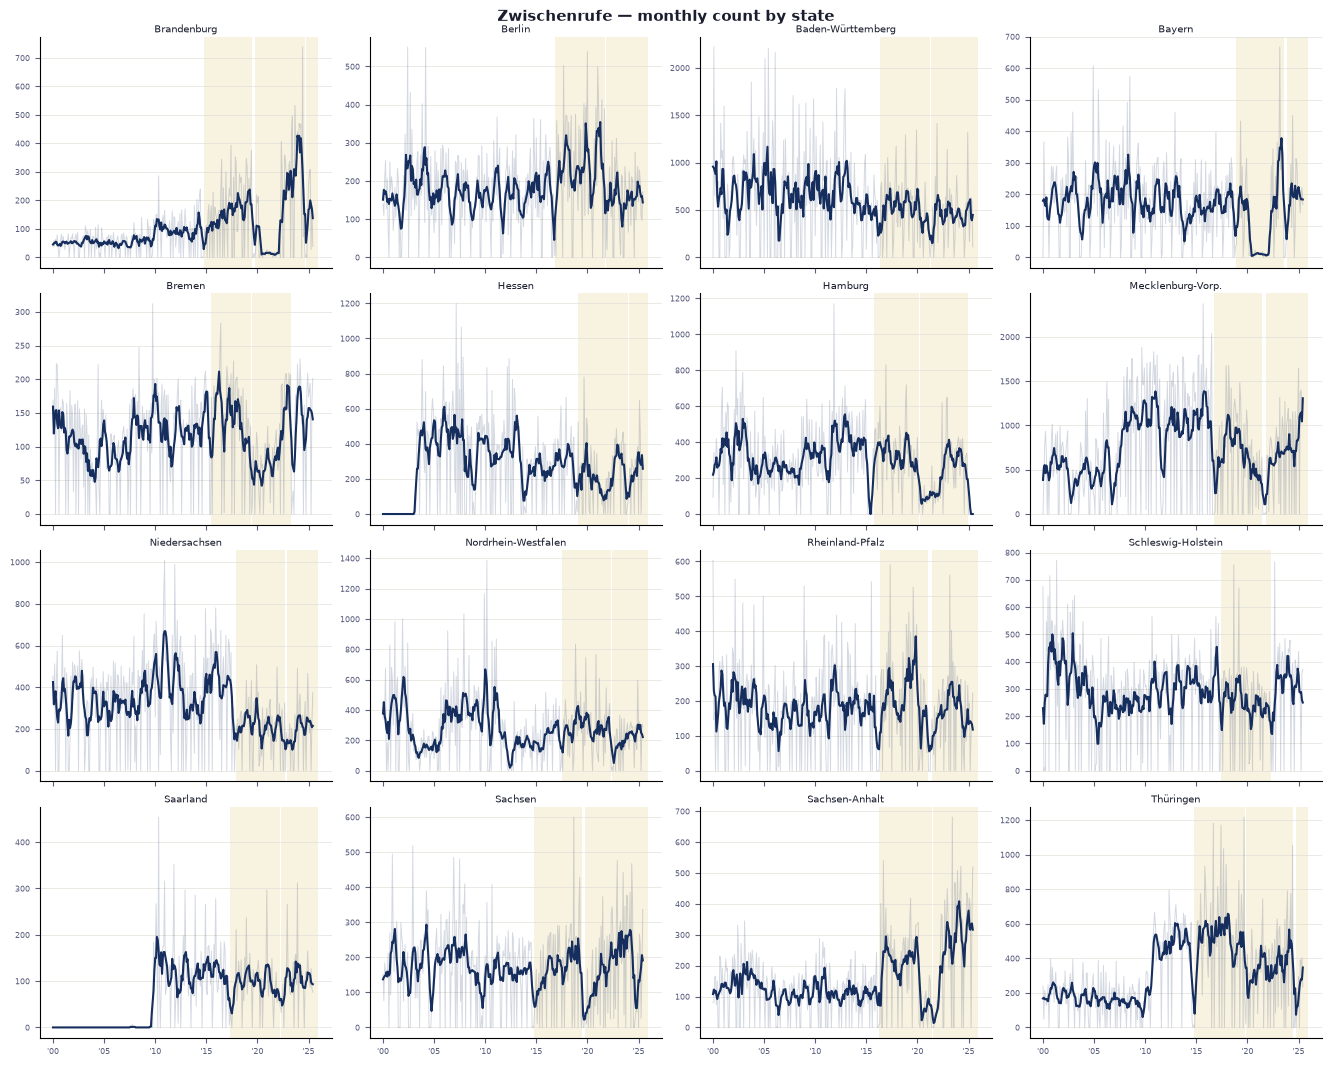

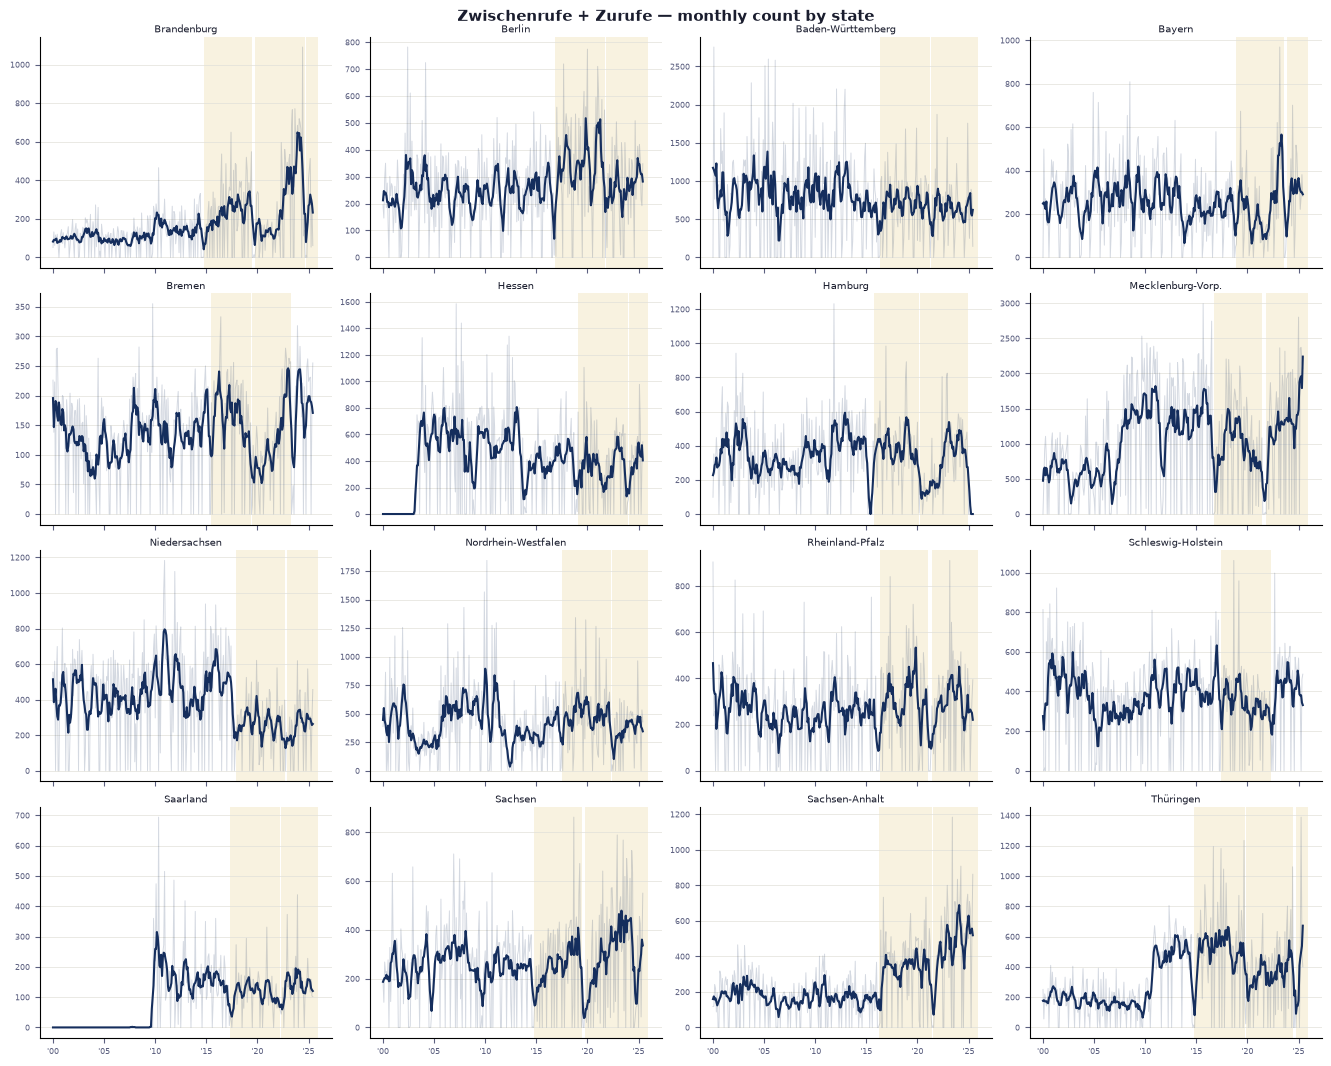

In [17]:
import math

STATE_LABELS = {
    "bw": "Baden-Württemberg",       "by": "Bayern",
    "be": "Berlin",                  "bb": "Brandenburg",
    "hb": "Bremen",                  "hh": "Hamburg",
    "he": "Hessen",                  "mv": "Mecklenburg-Vorp.",
    "ni": "Niedersachsen",           "nw": "Nordrhein-Westfalen",
    "rp": "Rheinland-Pfalz",         "sl": "Saarland",
    "sn": "Sachsen",                 "st": "Sachsen-Anhalt",
    "sh": "Schleswig-Holstein",      "th": "Thüringen",
}


def plot_states(data, title, y_fmt, filename, roll=6, ncols=4, presence=None):
    """Small-multiples monthly time series, one panel per state (single series).

    Parameters
    ----------
    data    : DataFrame  Monthly values, columns = state codes, index = Timestamps.
    title   : str        Figure suptitle.
    y_fmt   : callable   Y-tick formatter, e.g. ``lambda y, _: f"{y:.0f}"``.
    filename: str        Output stem; saved as .pdf + .png to PROC/.
    roll    : int        Centred rolling-average window in months (default 6).
    ncols   : int        Subplot columns (default 4 → 4 × 4 for 16 states).
    presence: dict       Optional {state_code: [(start, end), ...]} — shaded
                         spans marking periods the state's parliament had AfD
                         seats (see AFD_PRESENCE). Multiple disjoint intervals
                         per state render as separate shaded blocks, correctly
                         showing exit/re-entry gaps (Bremen, Schleswig-Holstein).
    """
    states = sorted(data.columns)
    nrows  = math.ceil(len(states) / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.3, nrows * 2.6),
                             constrained_layout=True, sharex=True, sharey=False)
    fig.suptitle(title, fontsize=10.5, fontweight="bold", color="#1A1D2E", y=1.01)

    for i, st in enumerate(states):
        ax  = axes.flat[i]
        raw = data[st]
        ax.plot(data.index, raw,
                color=NAVY, alpha=0.18, linewidth=0.7)
        ax.plot(data.index, raw.rolling(roll, center=True, min_periods=3).mean(),
                color=NAVY, linewidth=1.5)
        ax.set_title(STATE_LABELS.get(st, st.upper()), fontsize=7, pad=3, color="#1A1D2E")
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=6, colors="#5C6080")
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(y_fmt))
        ax.grid(axis="y", color="#E1E0D9", linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)
        if presence and st in presence:
            for start, end in presence[st]:
                ax.axvspan(start, end, color=GOLD, alpha=0.12, zorder=0.5, linewidth=0)

    for j in range(len(states), len(axes.flat)):
        axes.flat[j].set_visible(False)

    fig.savefig(PROC / f"{filename}.pdf", bbox_inches="tight")
    fig.savefig(PROC / f"{filename}.png", dpi=150, bbox_inches="tight")
    plt.show()


# ── Figure A: Zwischenruf only ────────────────────────────────────────────────
plot_states(
    state_monthly_zr,
    title    = "Zwischenrufe — monthly count by state",
    y_fmt    = lambda y, _: f"{y:.0f}",
    filename = "plot_zr_by_state_count",
    presence = AFD_PRESENCE,
)

# ── Figure B: Zwischenrufe + Zurufe combined ─────────────────────────────────
plot_states(
    state_monthly_zrzr,
    title    = "Zwischenrufe + Zurufe — monthly count by state",
    y_fmt    = lambda y, _: f"{y:.0f}",
    filename = "plot_zrzr_by_state_count",
    presence = AFD_PRESENCE,
)


**Monthly Zwischenruf + Zuruf counts by party and state — small multiples (4 × 4)**

- **Data:** Zwischenruf + Zuruf events; `party_canonical` exploded on `|` so multi-party rows (e.g. `"spd|cdu"`) contribute one count to each party. Six major parties shown.
- **Visualisation:** one coloured line per party per panel; faint = raw monthly, solid = 6-month rolling average; gold shaded region = period(s) AfD held seats in that state (see `AFD_PRESENCE`). Legend at figure bottom.


In [ ]:
def plot_states_party(data, parties, title, filename, y_fmt=lambda y, _: f"{y:.0f}",
                      roll=6, ncols=4, presence=None):
    """Small-multiples monthly time series, one coloured line per party per state panel.

    Parameters
    ----------
    data    : DataFrame  MultiIndex columns (state, party), index = Timestamps.
    parties : list       Party canonical names to plot (e.g. "CDU", "AfD"), in legend order.
    title   : str        Figure suptitle.
    filename: str        Output stem; saved as .pdf + .png to PROC/.
    y_fmt   : callable   Y-tick formatter, e.g. ``lambda y, _: f"{y:.0f}%"``
                         for shares (default: plain counts).
    roll    : int        Centred rolling-average window in months (default 6).
    ncols   : int        Subplot columns (default 4 → 4 × 4 for 16 states).
    presence: dict       Optional {state_code: [(start, end), ...]} — shaded
                         spans marking periods the state's parliament had AfD
                         seats (see AFD_PRESENCE).
    """
    states = sorted({st for st, _ in data.columns})
    nrows  = math.ceil(len(states) / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.3, nrows * 2.6),
                             constrained_layout=True, sharex=True, sharey=False)
    fig.suptitle(title, fontsize=10.5, fontweight="bold", color="#1A1D2E", y=1.01)

    legend_handles = []
    for i, st in enumerate(states):
        ax = axes.flat[i]
        for party in parties:
            if (st, party) not in data.columns:
                continue
            raw = data[(st, party)]
            c   = AFFILIATION_COLORS.get(party, "#808080")
            ax.plot(data.index, raw, color=c, alpha=0.18, linewidth=0.7)
            line, = ax.plot(data.index,
                            raw.rolling(roll, center=True, min_periods=3).mean(),
                            color=c, linewidth=1.5, label=party)
            if i == 0:
                legend_handles.append(line)

        ax.set_title(STATE_LABELS.get(st, st.upper()), fontsize=7, pad=3, color="#1A1D2E")
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=6, colors="#5C6080")
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(y_fmt))
        ax.grid(axis="y", color="#E1E0D9", linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)
        if presence and st in presence:
            for start, end in presence[st]:
                ax.axvspan(start, end, color=GOLD, alpha=0.12, zorder=0.5, linewidth=0)

    for j in range(len(states), len(axes.flat)):
        axes.flat[j].set_visible(False)

    if legend_handles:
        fig.legend(handles=legend_handles, loc="lower center",
                   ncol=len(legend_handles), fontsize=7.5,
                   framealpha=0.85, edgecolor="#DDE1EF",
                   bbox_to_anchor=(0.5, -0.02))

    fig.savefig(PROC / f"{filename}.pdf", bbox_inches="tight")
    fig.savefig(PROC / f"{filename}.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_states_party(
    state_party_monthly,
    parties  = MAJOR_CANONICAL,
    title    = "Zwischenrufe + Zurufe — monthly count by party and state",
    filename = "plot_zrzr_by_state_party",
    presence = AFD_PRESENCE,
)

plot_states_party(
    state_party_share,
    parties  = MAJOR_CANONICAL,
    title    = "Zwischenrufe + Zurufe — monthly share by party and state",
    filename = "plot_zrzr_by_state_party_share",
    y_fmt    = lambda y, _: f"{y:.0f}%",
    presence = AFD_PRESENCE,
)


## Pre/post-processing audit — state × year × party

Two complementary QA passes over `nsc.parquet`:

1. **Stratified sample** (below): 2–3 rows per (state, year, `party_canonical`) cell,
   joined back to the raw source row, for manual read-through across the full
   breadth of state/year/party combinations. Saved to CSV for independent review.
2. **Full-corpus heuristic scan** (further down): structural red-flag checks run over
   *all* ~4.8M interjection rows rather than a sample — cheap to compute, and far more
   reliable for catching low-frequency-but-systematic bugs than random sampling is.
   Findings from this pass, with root causes traced back into `nsc_rule_parser.py`,
   are written up in the markdown cell at the end.

`party_canonical` is exploded on `|` so a multi-party row contributes to every party's
stratum; rows with no captured party form their own `NONE` stratum (useful precisely
*because* it surfaces what the parser failed to attribute).

In [19]:
SAMPLE_PER_STRATUM = 3
SEED = 42

_par_min = paragraphs[["paragraph_id", "content"]].rename(columns={"content": "raw_paragraph"})

audit_base = nsc_df.copy()
audit_base["year"] = pd.to_datetime(audit_base["date"]).dt.year
audit_base["party_key"] = audit_base["party_canonical"].replace("", np.nan)

exploded = (
    audit_base.assign(party_key=audit_base["party_key"].str.split("|"))
    .explode("party_key")
)
exploded["party_key"] = exploded["party_key"].fillna("NONE")

strat_sample = (
    exploded.groupby(["state", "year", "party_key"], group_keys=False)
    .apply(lambda g: g.sample(min(len(g), SAMPLE_PER_STRATUM), random_state=SEED),
           include_groups=False)
)
# groupby.apply with include_groups=False drops the key columns — restore for readability
strat_sample = exploded.loc[strat_sample.index].merge(
    _par_min, on="paragraph_id", how="left"
)

DISPLAY_COLS = ["state", "year", "party_key", "nsc_type", "speaker_name", "role",
                "party_canonical", "content_text", "raw_segment", "raw_paragraph",
                "n_segments", "segment_idx"]
strat_sample = strat_sample[DISPLAY_COLS].sort_values(["state", "year", "party_key"]).reset_index(drop=True)

print(f"Strata: {exploded.groupby(['state','year','party_key']).ngroups:,}")
print(f"Sampled rows: {len(strat_sample):,}")

out_path = PROC / "audit_strat_sample_state_year_party.csv"
strat_sample.to_csv(out_path, index=False)
print(f"Saved → {out_path}")
strat_sample.head(20)

Strata: 3,574
Sampled rows: 16,020
Saved → /Users/anna/Library/CloudStorage/GoogleDrive-anle.werner.01@gmail.com/My Drive/my_projects/M.A. Parliament/Code and Data/data/processed/audit_strat_sample_state_year_party.csv


,state,year,party_key,nsc_type,speaker_name,role,party_canonical,content_text,raw_segment,raw_paragraph,n_segments,segment_idx
0,bb,2000,CDU,Beifall,,,SPD|CDU,Beifall,Beifall bei SPD und CDU,(Beifall bei SPD und CDU),1,0
1,bb,2000,CDU,Beifall,,,SPD|CDU|LINKE,Beifall,"Beifall bei SPD, CDU und PDS","(Beifall bei SPD, CDU und PDS - Vietze [PDS]: ...",2,0
2,bb,2000,CDU,Beifall,,,SPD|CDU,Beifall,Beifall bei SPD und CDU,(Beifall bei SPD und CDU),1,0
3,bb,2000,CDU,Beifall,,,SPD|CDU,Beifall,Beifall bei SPD und CDU,(Beifall bei SPD und CDU),1,0
4,bb,2000,GOV,Zuruf,,,GOV,Zuruf,Zuruf von Minister Prof. Dr. Schelter,(Zuruf von Minister Prof. Dr. Schelter),1,0
5,bb,2000,GOV,Zuruf,,,GOV,Zurufe,Zurufe von Minister Prof. Dr. Schelter und Min...,(Zurufe von Minister Prof. Dr. Schelter und Mi...,1,0
6,bb,2000,GOV,Beifall,,,GOV,,Beifall des Ministers Dr. Hackel,(Minister Dr. Hackel: Jawohl! - Beifall des Mi...,2,1
7,bb,2000,LINKE,Beifall,,,SPD|CDU|LINKE,Beifall,"Beifall bei SPD, CDU und PDS","(Beifall bei SPD, CDU und PDS - Vietze [PDS]: ...",2,0
8,bb,2000,LINKE,Beifall,,,LINKE,Beifall,Beifall bei der PDS,(Beifall bei der PDS - Vereinzelt Beifall bei ...,2,0
9,bb,2000,LINKE,Zuruf,,,LINKE,Zurufe,Zurufe von der PDS,(Zurufe von der PDS),1,0


### Full-corpus heuristic scan

Ten structural red-flag checks run over all interjection rows (not a sample). Each
flags a *pattern*, not necessarily an error on every matched row — but every flag
below was spot-checked and traced to a confirmed root cause in `nsc_rule_parser.py`
(see the findings write-up at the end of this section).

In [20]:
audit_flags = {}

has_colon = inj["raw_segment"].str.contains(":", regex=False, na=False)

audit_flags["unknown_type"] = inj["nsc_type"] == "unknown"
audit_flags["party_other"] = inj["party_canonical"].str.contains(r'\bOTHER\b', na=False)
audit_flags["colon_but_no_content"] = (
    has_colon & (inj["content_text"].str.strip() == "") & (~inj["is_faction_only"])
)
audit_flags["speaker_name_junk"] = inj["speaker_name"].str.contains(r'[\[\]():\d]', na=False)
audit_flags["content_text_leading_junk"] = inj["content_text"].str.match(r'^[\]\)\:\-–,]', na=False)
audit_flags["party_raw_not_canonicalized"] = (
    (inj["party_raw"].str.strip() != "") & (inj["party_canonical"].str.strip() == "")
)
audit_flags["long_unsplit_segment"] = inj["raw_segment"].str.len() > 250
audit_flags["qualifier_but_unknown_type"] = (inj["qualifier"] != "") & (inj["nsc_type"] == "unknown")
audit_flags["named_speaker_suspicious"] = inj["is_named_speaker"] & inj["speaker_name"].str.contains(
    r'fraktion|abgeordnete|ausschuss', case=False, na=False)
audit_flags["whole_house_and_party"] = inj["is_whole_house"] & (inj["party_canonical"].str.strip() != "")

audit_summary = pd.DataFrame(
    {k: [v.sum(), round(v.mean() * 100, 3)] for k, v in audit_flags.items()},
    index=["n", "pct_of_interjections"],
).T.sort_values("n", ascending=False)
audit_summary

,n,pct_of_interjections
party_other,90712.0,2.206
unknown_type,22740.0,0.553
content_text_leading_junk,18336.0,0.446
colon_but_no_content,12073.0,0.294
named_speaker_suspicious,10931.0,0.266
speaker_name_junk,2099.0,0.051
long_unsplit_segment,1104.0,0.027
qualifier_but_unknown_type,170.0,0.004
whole_house_and_party,107.0,0.003
party_raw_not_canonicalized,0.0,0.000


In [21]:
def inspect_flag(name, n=8, seed=1):
    """Show example rows for one of the audit_flags keys."""
    mask = audit_flags[name]
    cols = ["state", "nsc_type", "speaker_name", "party_raw", "party_canonical", "content_text", "raw_segment"]
    sample = inj[mask][cols].sample(min(n, mask.sum()), random_state=seed)
    print(f"{name}  (n={mask.sum():,}, {mask.mean()*100:.3f}%)\n")
    for _, r in sample.iterrows():
        print(f"[{r['state']} | {r['nsc_type']!r} | speaker={r['speaker_name']!r} | "
              f"party_raw={r['party_raw']!r} | party_canon={r['party_canonical']!r}]")
        print(f"  raw:     {r['raw_segment']!r}")
        print(f"  content: {r['content_text']!r}\n")
    return sample

inspect_flag("unknown_type")

unknown_type  (n=22,740, 0.553%)

[mv | 'unknown' | speaker='' | party_raw='' | party_canon='']
  raw:     'Rainer Albrecht, SPD, und Simone Oldenburg, DIE LINKE: Oh!'
  content: ''

[hh | 'unknown' | speaker='' | party_raw='' | party_canon='']
  raw:     'Dirk Nockemann Partei Rechtsstaatlicher Offensive: Stoff ist teurer geworden: Verknappung!'
  content: ''

[mv | 'unknown' | speaker='' | party_raw='' | party_canon='']
  raw:     'Sebastian Ehlers, CDU, und Dr. Ralph Weber, AfD: Dringlichkeit!'
  content: ''

[hh | 'unknown' | speaker='' | party_raw='' | party_canon='']
  raw:     'Norbert Frühauf Partei Rechtsstaatlicher Offensive'
  content: ''

[be | 'unknown' | speaker='' | party_raw='' | party_canon='']
  raw:     'RBm Wowereit: Gibt auch mehr Geld!'
  content: ''

[by | 'unknown' | speaker='' | party_raw='' | party_canon='']
  raw:     'Abgeordneter Muthmann (fraktionslos) hebt seine Hand'
  content: ''

[be | 'unknown' | speaker='' | party_raw='' | party_canon='']
  raw:     

,state,nsc_type,speaker_name,party_raw,party_canonical,content_text,raw_segment
2543903,mv,unknown,,,,,"Rainer Albrecht, SPD, und Simone Oldenburg, DI..."
1907533,hh,unknown,,,,,Dirk Nockemann Partei Rechtsstaatlicher Offens...
2504870,mv,unknown,,,,,"Sebastian Ehlers, CDU, und Dr. Ralph Weber, Af..."
1897983,hh,unknown,,,,,Norbert Frühauf Partei Rechtsstaatlicher Offen...
214446,be,unknown,,,,,RBm Wowereit: Gibt auch mehr Geld!
1173717,by,unknown,,,,,Abgeordneter Muthmann (fraktionslos) hebt sein...
179234,be,unknown,,,,,Bm Dr. Werthebach: Nun sind wir aber gespannt!
4595194,st,unknown,,,,,"Holger Hövelmann, SPD, und Dr. Falko Grube, SP..."


### Findings: what's captured, what's missed, what's introduced wrong

Based on the full-corpus scan above plus manual read-through of ~150 rows drawn from
the state × year × party stratified sample (`audit_strat_sample_state_year_party.csv`),
spanning all 16 states and 2000–2025.

#### Captured well (working as intended)

- Single named-speaker + single-party interjections, in all four format families
  (square/round/comma/space) — clean `speaker_name` / `party_canonical` / `content_text`.
- Simple single-party attributions (`"Beifall bei der SPD"`).
- Multi-party lists **with 3+ parties joined by multiple commas** correctly fall through
  to the faction-attribution branch and capture every party
  (e.g. `"Beifall bei der SPD, der CDU, den LINKEN, den BÜNDNISGRÜNEN und der Staatsregierung"`
  → `SPD|CDU|LINKE|GRÜNE|OTHER`, all five entities present).
- Multi-type pipe-joining (`"Heiterkeit und Beifall"` → `Heiterkeit|Beifall`) and
  multi-party pipe-joining both work as designed for the cases that reach them.
- Qualifier extraction (`vereinzelt`, `anhaltend`, `lebhaft`, …), OCR hyphen-linebreak
  repair, and glocke-speaker extraction all perform as documented.

#### Not captured (silently missing)

1. **`unknown_type`: 36,268 rows (0.75% of interjections).** Two distinct causes:
   - **Root cause, confirmed:** [`_IS_MISLABELLED`](../preprocessing/nsc_rule_parser.py#L334)
     is defined as `^(?:alt1|alt2|...|chair-change|...)"` — the `^` sits *outside* the
     whole alternation, so it anchors **every** alternative to the very start of the
     string, not just the first one. Row-type classification runs on the *whole raw row*
     before splitting, so a genuine narrative aside (chair takeover, someone leaving the
     room) that appears as **segment 2+** of a multi-segment row is never caught — e.g.
     `"(Beifall – Erste Vizepräsidentin Mareike Engels übernimmt den Vorsitz.)"`
     contains a clean chair-change pattern, but because it's preceded by `"Beifall – "`,
     the row classifies as `interjection`, gets split into two segments, and the second
     segment (with no type keyword, no name match) lands in `nsc_type="unknown"` with a
     real named person and role silently lost. Verified directly against the compiled
     regex — 44 rows share this exact chair-change text alone; the same anchor bug
     likely affects the noise/procedural/collective-narrative alternatives in the same
     pattern whenever they aren't at the very start of the row. **Not fixed** — lower
     priority since it affects row classification, not party attribution (see below).
   - Genuinely ambiguous fragments (`"Warum denn?"`, `"Sie müssen nicht!"`) with no type
     keyword and no name pattern — arguably correctly left unclassified, since there's no
     reliable signal to classify on.
2. **`colon_but_no_content`: 16,464 rows (0.34%).** Raw text has a clear `": spoken text"`
   but no upstream regex matched a speaker/party format, so `content_text` ends up empty
   and the quote is dropped entirely (e.g. `"Norbert Frühauf Partei Rechtsstaatlicher
   Offensive: Was ist daran problematisch?"` — no comma/bracket/paren delimiter before
   the party name in the source text, so no format regex fires). **Not fixed** — long
   tail of one-off formats, not worth chasing (see risk note below).

#### Wrong things introduced (mis-parses, not just gaps) — ✅ FIXED

1. ~~Multi-party lists silently drop the first-listed party~~ — **fixed.**
   [`extract_named_speaker`](../preprocessing/nsc_rule_parser.py#L527) always ran *before*
   the correct faction-list branch; if any no-colon "named speaker" fallback regex
   produced *any* match — even a wrong one — the correct multi-party path was skipped.
   - **Comma-format states (mv, rp, sn, st, th):**
     [`_NAME_COMMA_NO_COLON`](../preprocessing/nsc_rule_parser.py#L237)'s `[A-ZÄÖÜ]`
     capital-letter gate was silently neutered by the pattern's own `re.I` flag. Fixed
     with a scoped inline flag, `(?-i:[A-ZÄÖÜ])`, which restores case-sensitivity for
     just that one class without touching the rest of the pattern (still needs `re.I`
     for "Abg./Frau/Herr" prefix matching).
   - **`elif primary_type:` fallback** (used when no preposition-led faction phrase is
     present, e.g. `"Beifall der FDP, der SPD und ..."`): previously required the text
     right after the type keyword to start uppercase, which a leading German article
     ("der"/"des"/...) always defeated. Fixed by stripping one leading article before
     the check — **but only accepting the result if it actually resolves to a real,
     non-`OTHER` party** via `canonicalize_party_list`. This guard was added after an
     initial version (stripping the article unconditionally) turned out to also fire on
     non-party role/name attributions like `"Glocke der Präsidentin"` or `"Zuruf des
     Ministers Stratthaus"`, fabricating a bogus `OTHER` party where none should exist —
     caught by re-running the full pipeline and diffing before/after, not by inspection.
   - **Verified impact** (full-corpus rerun, `nsc.parquet` row count unchanged at
     4,920,872): **119,543 rows (2.4%) changed `party_canonical`**, essentially all
     recovering a real party that was previously dropped (e.g. `"" → CDU`: 18,757 rows;
     `OTHER → LINKE`: 9,855 rows recovering the PDS pattern; `FDP|GRÜNE → SPD|FDP|GRÜNE`:
     2,390 rows). As a side effect of the `_NAME_COMMA_NO_COLON` fix, the *same*
     mechanism was also fabricating bogus attributions on unrelated text (e.g. treating
     arbitrary lowercase continuation prose as a "party") — those are now correctly
     empty too. Net effect: `party_canonical` containing `OTHER` dropped from 4.950%
     to 4.633% of interjections, i.e. **cleaner, not just more populated**.
2. ~~`_FACTION_PREP` truncates at any period or hyphen~~ — **fixed.** Added `.` and `-`
   to the capture class in [`_FACTION_PREP`](../preprocessing/nsc_rule_parser.py#L301).
   Confirmed: `"Unruhe bei der Linksfraktion.PDS und der FDP"` now correctly resolves to
   `party_canonical="LINKE|FDP"` instead of `party_raw="Linksfraktion"` / `"OTHER"`.

#### Wrong things introduced — not fixed (risk of a new error exceeding the fix)

3. **Bracket-format rows leak into nominally "space"-format states.** BW rows like
   `"Abg. Dr. Heinrich Fiechtner [fraktionslos]: Zur Sache!"` use square-bracket party
   notation even though BW's `STATE_CONFIG` fmt is `"space"`; the fallback `_KNOWN_PARTY`
   match leaves bracket residue in `speaker_name`/`content_text`. Low volume (2,666 rows,
   0.055%); left open pending a decision on whether to add a bracket-aware branch to the
   space format or treat these BW rows as their own format variant.
4. **Bare attribution stubs fabricate a `Zwischenruf` event with zero content**
   (`"Vizepräsidentin Ries"`, `"Abg. Kemmerich"`) via the
   [`_BARE_NAME_ONLY`](../preprocessing/nsc_rule_parser.py#L243) fallback. Left open: the
   same short bare-name/role shape is also how a *legitimate* no-content attribution
   looks elsewhere in the corpus, so there's no reliable textual signal to separate
   "truncated stub" from "intentional bare attribution" — any tightening here risks
   trading one error type for another.
5. **`party_canonical == "OTHER"` conflates two different things** (now 4.63% of
   interjections post-fix): genuinely unmapped/non-party entities correctly bucketed as
   OTHER by design (`"der Staatsregierung"`, a historical minor party like DVU or the
   Schill-Partei), versus any remaining mechanical-failure share. Not a bug — a labeling
   ambiguity worth keeping in mind if `OTHER` is ever read as "minor party" downstream.

#### Left open for a future pass

The `_IS_MISLABELLED` anchor bug (finding 1 in "not captured," above) needs the pattern
split into two correctly-scoped regexes (some alternatives should stay anchored to
row-start, others — the narrative-aside ones — should not); that's a real design
decision about which alternative belongs where, not a one-line change, so it wasn't
attempted in this pass.

### Category-construct critique and a third fix

A follow-up pass questioning what the *categories themselves* mean, not just parsing
correctness — prompted by treating `nsc_type` and `party_canonical` as the actual
variables for the AfD-entry analysis rather than as parser output to QA.

#### 3. Multi-type pipe-joining order-dependence — ✅ fixed

`nsc_type` for co-occurring reactions was joined in **source-text order**, so
`"Heiterkeit und Beifall"` → `Heiterkeit|Beifall` while `"Beifall und Heiterkeit"` →
`Beifall|Heiterkeit` — two labels for the same substantive combination, differing only
by which word a particular stenographer happened to write first. Fixed in
[`parse_segment`](../preprocessing/nsc_rule_parser.py#L729): the keyword set is now sorted
alphabetically before joining, so the label is a function of *which types co-occurred*,
never *the order they were phrased in*.

**Verified impact** (full-corpus rerun, row count unchanged at 4,920,872): distinct
`nsc_type` values dropped from 272 → 169 (multi-type combos: 252 → 149 distinct
strings). Example: `Heiterkeit|Beifall` (16,705 rows) and `Beifall|Heiterkeit` (4,367
rows) — previously separate categories purely by phrasing order — now correctly
consolidate into one `Beifall|Heiterkeit` (21,072 rows).

Note this doesn't fix the deeper issue that `primary_type = nsc_type.split("|")[0]`
(used in the time-series cells above) still picks *one* of several co-occurring types
as "the" type — it's now at least deterministic (alphabetically first) rather than
phrasing-order-dependent, but arbitrarily privileging one label over the others it
co-occurred with is itself worth reconsidering if multi-type rows are analytically
important (e.g. treat as a multi-label indicator matrix instead of picking one).

#### Zuruf vs. Zwischenruf — not a behavioral distinction; don't merge on the label

Confirmed against [`parse_segment`](../preprocessing/nsc_rule_parser.py#L744-749): if an
explicit type keyword appears anywhere in the segment text (including the literal words
"Zuruf"/"Zwischenruf" themselves), that keyword becomes `nsc_type` regardless of whether
a name was also captured. The `Zwischenruf`/`Zuruf` labels only arise as a *fallback* —
`Zwischenruf` when no keyword matched but a name was extracted, `Zuruf` when no keyword
matched and only a party was extracted. So the label is not a clean partition on
attribution:

| `nsc_type` | n | `is_named_speaker` = True | has `content_text` |
|---|---|---|---|
| `Zuruf` | 665,088 | **56.8%** | 35.8% |
| `Zwischenruf` | 1,639,554 | 99.9% | 88.4% |

Over half of `Zuruf`-labeled rows *do* have a named speaker (e.g. `"Zuruf des Abg.
Schippel [SPD]"`) — the label only reliably means "no type-keyword conflict was
inferred," not "unattributed." **Recommendation, adopted:** merge `Zuruf`/`Zwischenruf`
into one category for analysis, and use `is_named_speaker` and
`content_text`-non-empty directly as the real attribution/completeness variables — they
already encode exactly the clearly-attributable-vs-not and has-content-vs-not
distinction the label was an imperfect proxy for, without needing two separate
`nsc_type` values to carry it.

#### The row-level filter categories are not all the same kind of thing

- **`garbled` — dead in v3.** Triggers only on a literal `±` (v2 Hessen OCR/encoding
  artifact per the module docstring). Confirmed: **0 rows** in the current data.
  Legacy scaffolding with nothing left to catch.
- **`noise` (2,573 rows) — not interjection content at all.** Matches bibliographic/
  procedural metadata that got the `affiliation == "nsc"` tag upstream in the *source*
  StateParl corpus by mistake: bill references (`"(Drucksache 15/385)"`), agenda-item
  numbers, `"(Siehe Anlage 1)"`, reading-stage markers. These were never reaction
  annotations to begin with; the row filter is catching an upstream labeling artifact,
  not doing any interpretive work of its own.
- **`mislabelled` (17,455 rows) — narrative stage-direction using the same bracket
  notation as genuine reactions.** Catches sentences describing a *named individual's
  physical action* — `"(Heinrich Aller [SPD] begibt sich zum Redepult)"` (walks to the
  podium), `"(Herr Weigelt, CDU, lacht)"` (an individual laughing, as narrated fact —
  distinct from the *collective* `Heiterkeit`/`Lachen` reaction type), head-shaking,
  chair-handover narration, collective-movement narration ("die Abgeordneten erheben
  sich"). The line it draws: *reaction to speech* vs. *stage direction describing what
  someone visibly did*. As noted above, this filter is `^`-anchored to row-start, so an
  unknown share of this same content leaks into `unknown` instead when it occurs as
  segment 2+ of a multi-segment row.
- **`unknown` (~36,500 rows) — a different kind of category: a *segment-level residual*,
  not a row-level content-pattern decision.** `noise`/`mislabelled`/`Prozedural`/`glocke`
  are all decided on the whole row *before* splitting — "does this row's text look like
  non-reaction content." `unknown` only exists for rows that passed that screen (accepted
  as plausible interjection content) and were then split into segments — assigned when,
  after splitting, no type keyword, name, or party could be extracted from a segment. It
  mixes two different things: (a) genuine mislabelled-shaped content that leaked past the
  anchor bug above, and (b) short bare fragments (`"Warum denn?"`) with no structural cue
  to parse at all, which are plausibly genuine but uninterpretable as given.

### Two more fixes: government/presiding-officer actors, and narration-vs-quote contamination

#### `OTHER` conflated government/institutional actors with genuinely unmapped parties — ✅ fixed

`party_canonical == "OTHER"` was catching two very different things under one label:
real unmapped parties, *and* references to ministers, the cabinet collectively
(`"Staatsregierung"`/`"Landesregierung"`/`"Regierungsbank"`), mayors, senators, and the
chamber's own presiding officer (`"Präsident/in"`) — all of which are identifiable
government/institutional actors, not unknown parties. This mattered specifically because
these actors are meant to map to `affiliation_derived = "gov"` / `"pre"` (the same
StateParl affiliation codes already used for the primary-speaker `role` field via
`_ROLE_TO_AFF`), not get lost in a residual bucket.

Added two new canonical values in
[`canonicalize_party`](../preprocessing/nsc_rule_parser.py#L397): `GOV` (ministers,
Ministerpräsident/in, Staatsregierung/Landesregierung/Regierungsbank, Bürgermeister/in,
Senator/in, Staatssekretär/in) and `PRE` (Präsident/in, Vizepräsident/in, Schriftführer/in
— chamber leadership, distinct from the executive). Checked *after* the real party-name
patterns (so an actual party name always wins) and *before* the `OTHER` fallback.
`Ministerpräsident/in` is deliberately matched by the GOV pattern rather than the
presiding-officer one, since the Minister-President heads the state executive — a
different office from the Landtag's own `Präsident/in` (speaker of the house) despite
the shared word root. `_PARTY_TO_AFF` extended with `"GOV": "gov"`, `"PRE": "pre"` so
`affiliation_derived` reflects this for multi-entity rows too (e.g. `"SPD|GOV"` →
`affiliation_derived="gov|spd"`).

**Verified impact** (full-corpus rerun, row count unchanged at 4,920,872):
`party_canonical` containing `OTHER` dropped from 4.633% → 4.219% (227,990 → 207,611
rows); **27,722 rows now correctly tag `GOV`, 9,268 tag `PRE`**. Spot-checked ~40 diffed
rows: real party attributions are always preserved (e.g. `"Beifall bei der CDU, der FDP
und der Staatsregierung"`: `CDU|FDP|OTHER` → `CDU|FDP|GOV`, never touching CDU/FDP) —
only the previously-mislabeled fragment moves from `OTHER` to `GOV`/`PRE`. Note:
`KOALITION`/`OPPOSITION`/`FRAKTIONSLOS` remain distinct from real party names in this
same column (a separate, known category-type mismatch — see the critique above); they
are not parties either, but resolving *which* parties they refer to requires an external
`(state, period) → governing coalition` lookup that doesn't exist in this pipeline, so
they're deliberately left as-is rather than guessed at.

#### `is_whole_house` and `qualifier` were scanning quoted speech, not just narration — ✅ fixed

Both regex checks ran `.search()` over the *entire* segment string, which includes any
quoted spoken content after a colon — so a speaker's own words could accidentally trigger
a narrator-only signal. Confirmed example: `"Jörg Bode [FDP]: Es gibt nur Beifall bei
dieser Seite des Hauses!"` — Bode is *saying* "there's only applause from one side of the
house," but `is_whole_house` fired anyway, because `_WHOLE_HOUSE` matched inside his
quoted words, not because the narrator described a whole-house reaction.

Fixed in [`parse_segment`](../preprocessing/nsc_rule_parser.py#L687) by reusing the same
"text before the first colon" boundary (`scan_text`) that the multi-type keyword scan
already correctly used — computed once at the top of the function now, and applied to
`is_whole_house`, `qualifier`, *and* the multi-type scan consistently. Segments with no
colon (attribution-only, no quoted content) are unaffected. Verified: the Jörg Bode case
now correctly returns `is_whole_house=False`; a fabricated regression case
(`"Klein [SPD]: Wir brauchen mehr vereinzelten Einsatz!"`, where "vereinzelten" is an
ordinary word inside the quote, unrelated to reaction intensity) no longer sets
`qualifier="vereinzelten"`; genuine narrator-side cases (`"Allgemeiner Beifall"`,
`"Vereinzelter Beifall bei der SPD"`) are unaffected.

**Verified impact**: `is_whole_house` true-count 25,458 → 25,280 (−178); rows with a
non-empty `qualifier` 241,079 → 237,779 (−3,300). Small in volume — this contamination
pattern is rare (matches the earlier `whole_house_and_party` audit flag, only 236/4.8M
rows) — but each instance was a genuine mislabel, not noise, so worth having fixed.

### Reassessment: weighing correct vs. wrong extraction, three more fixes

A second read-through pass — 210 rows stratified across `nsc_type`, `GOV`/`PRE`,
`is_whole_house`, and `qualifier` — measured against corpus-wide prevalence rather than
sample impressions alone. Found the largest data-quality issue in this whole audit.

#### Bug B — `speaker_name` contaminated with a leading type-keyword+preposition — ✅ fixed, was 28.8% of all named-speaker rows

`"Gegenruf des Abg. Wolfgang Drexler SPD: Richtig! Toll!"` → `speaker_name="Gegenruf des
Abg. Wolfgang Drexler"` instead of `"Wolfgang Drexler"`. Root cause: the comma/space-format
name regexes already special-cased stripping the single word `"zwischenruf"` as an
optional prefix, and square-format has its own separate (also incomplete) strip — but no
other type keyword (`Zuruf`, `Gegenruf`, `Lachen`, `Heiterkeit`, compounds like
`"Heiterkeit und Zuruf"`, …) got stripped in any format. Fixed with a new
[`_strip_leading_type_kw_run`](../preprocessing/nsc_rule_parser.py#L169) helper, applied
once at the top of `extract_named_speaker` — before the Minister checks and every
format-specific branch — so every downstream path benefits uniformly. Only fires when the
segment actually starts with a type keyword; everything else is untouched.

**Verified impact**: speaker_name contamination among named rows: **719,003 → 7 rows
(28.8% → 0.0%)**. Broader side effect, fully explained and spot-checked (10/10 sampled):
269,174 rows that were previously *fabricating* a named speaker from pure party-list text
(e.g. `"Beifall bei der FDP/DVP, den Grünen, der CDU und der SPD"` → bogus speaker
`"Beifall bei der"`, only 1 of 4 parties captured) now correctly resolve to
`is_named_speaker=False` with **every** party captured. This is the same root mechanism
as the multi-party-first-entry-drop bug flagged (and deliberately left open) in the first
audit pass — fixed here as a side effect, not separately targeted.

#### Bug A — real quoted content silently discarded — ✅ fixed, was 59,652 rows (1.24%)

`"Zuruf von der CDU: Das ist Blödsinn!"` → `content_text="Zuruf"` (the keyword itself)
instead of the actual quote. Root cause:
[`_FACTION_PREP`](../preprocessing/nsc_rule_parser.py#L301)'s capture class didn't include
`:`, so its own colon-splitting logic just below the match — already written — could
never fire; the real post-colon content was never even captured, and the code silently
fell back to the pre-preposition text (the bare type keyword) as a substitute. Fixed by
widening the capture to `(.+)` with `DOTALL` (matching how other content-capture groups
in this module already work, e.g. `_NAME_ROUND`'s `.*$`) instead of a narrow character
class — trailing punctuation is preserved too. **Verified impact**: 59,652 → 17 rows.

#### Bug C — slash-compound party names split into a real party plus a spurious `OTHER` — ✅ fixed, was 109,470 rows (2.27%)

`canonicalize_party("FDP/DVP")` alone already correctly returns `"FDP"` — the pattern was
written for exactly this — but `canonicalize_party_list` split on `/` as a generic list
separator *before* trying the whole fragment, breaking the compound-aware patterns.
Concentrated overwhelmingly in BW, where `FDP/DVP` is the standard list name (64,486
rows alone), plus `B90/GRÜNE`, `BVB/FW`. Fixed by trying the whole fragment against
`_PARTY_MAP` first and falling back to splitting on `/` only if that resolves to `OTHER`.
Known tradeoff, disclosed and accepted: a genuine two-different-entity compound not
covered by any single pattern (`"Freie Wähler/BMV"`, 764 rows) now silently resolves to
just `FW` — the second entity was already unrecognized before (contributing an
uninformative `OTHER`), so this isn't a loss of a previously-correct signal, just a
change from explicit-but-uninformative to implicit.

**Combined verified impact** (row count unchanged at 4,920,872): `party_canonical`
containing `OTHER` dropped from 4.30% → 2.19% of interjections (combines this fix with
the earlier GOV/PRE fix).

#### Smaller, unfixed finding: ASCII-hyphen separator gap in em-dash-only states

`be/by/he/hh/mv/rp/sn/sl` only recognize the em-dash `–` as a segment separator in
`STATE_CONFIG`, not the ASCII hyphen `-` (unlike `hb/ni/nw/sh/st/th`, which accept both).
When source text uses a plain hyphen, long multi-event rows fail to split, merging
unrelated content into one garbled segment — confirmed 3,879 rows (~0.08%), concentrated
in `by`/`sl`/`hh`/`rp`. Flagged, not fixed this pass — low volume, and worth checking
whether it's genuine source-text variation or an OCR/digitization-era artifact before
just widening the separator regex for those states.